**Exercise 2**

1. Load the iris data set using sklearn datasets

2. Set X to contain the feature matrix

3. Set y to contain the target vector​‌

4. Fit a DB Clustering model with 3 clusters​‌

5. Get resulting groups​‌

6. For each group, find the most ocurring flower type for each group

7. Having the labels for each group, see the confusion matrix and the accuracy score

8. Use the above clustering evaluation metrics (with/without true y) to evaluate the performance of the clustering

9. Do we really see the flower groups here or should there be more/less?

10. Plot using the elbow method. Plot using silhoutte coefficient.

11. Does scaling the data improve the performance of the clustering

In [19]:
# Import libs

from sklearn import datasets
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# Load iris dataset

iris = datasets.load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Feature names:", feature_names)
print("Target names:", target_names)

Feature matrix shape: (150, 4)
Target vector shape: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


In [21]:
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["flower_type"] = [target_names[i] for i in y]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_type
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [22]:
# check number of clusters and noise points
unique_groups = np.unique(groups)
clusters_only = [group for group in unique_groups if group != -1]
number_of_clusters = len(clusters_only)
number_of_noise_points = np.sum(groups == -1)

print("Number of clusters excluding noise:", number_of_clusters)
print("Number of noise points:", number_of_noise_points)

Number of clusters excluding noise: 3
Number of noise points: 29


In [23]:
# Find best eps

def find_eps_for_n_clusters(X_data, target_clusters=3, min_samples=5):
    eps_values = np.arange(0.10, 2.01, 0.01)

    results = []

    for eps in eps_values:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_data)

        clusters = set(labels)
        clusters.discard(-1)

        n_clusters = len(clusters)
        n_noise = np.sum(labels == -1)

        if n_clusters == target_clusters:
            if len(set(labels)) > 1:
                sil_score = silhouette_score(X_data, labels)
            else:
                sil_score = np.nan

            results.append({
                "eps": round(eps, 2),
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "noise_points": n_noise,
                "silhouette_score": sil_score
            })

    return pd.DataFrame(results)

eps_search_results = find_eps_for_n_clusters(X, target_clusters=3, min_samples=5)
eps_search_results

,eps,min_samples,n_clusters,noise_points,silhouette_score
0,0.23,5,3,118,-0.226025
1,0.24,5,3,118,-0.226025
2,0.30,5,3,96,-0.052064
3,0.42,5,3,29,0.357892


In [24]:
# Find best eps

best_row = eps_search_results.sort_values(
    by="silhouette_score",
    ascending=False
).iloc[0]

best_eps = best_row["eps"]

print("Best eps:", best_eps)
print(best_row)

Best eps: 0.42
eps                  0.420000
min_samples          5.000000
n_clusters           3.000000
noise_points        29.000000
silhouette_score     0.357892
Name: 3, dtype: float64


In [25]:
# Fit a dbscan cluster model

dbscan = DBSCAN(eps=0.42, min_samples=5)

groups = dbscan.fit_predict(X)

print("Resulting groups:")
print(groups)

print("Unique groups:", np.unique(groups))

Resulting groups:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1  1 -1  1  1 -1  1 -1  1 -1  1  1  1 -1  1  2  1
  2  1  1  1  1  1  1 -1  1  1  1  2  1 -1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1 -1  2  2  2  2 -1 -1 -1 -1 -1  2  2  2  2 -1  2  2 -1 -1 -1
  2  2 -1  2  2 -1  2  2  2 -1 -1 -1  2  2 -1 -1  2  2  2  2  2  2  2  2
  2  2  2  2  2  2]
Unique groups: [-1  0  1  2]


In [29]:
# find the most occurring flower type

cluster_to_label = {}

for group in np.unique(groups):
    if group == -1:
        continue

    actual_labels_in_group = y[groups == group]
    most_common_label = np.bincount(actual_labels_in_group).argmax()

    cluster_to_label[group] = most_common_label

print("Cluster to flower label mapping:")

for group, label in cluster_to_label.items():
    print(f"Group {group} is mostly {target_names[label]}")

Cluster to flower label mapping:
Group 0 is mostly setosa
Group 1 is mostly versicolor
Group 2 is mostly virginica


In [30]:
# Convert dbscan groups into predicted labels

y_pred = np.full_like(y, fill_value=-1)

for group in np.unique(groups):
    if group == -1:
        continue

    y_pred[groups == group] = cluster_to_label[group]

df["predicted_label"] = y_pred
df["predicted_flower"] = [
    target_names[label] if label != -1 else "noise"
    for label in y_pred
]

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_type,predicted_label,predicted_flower
0,5.1,3.5,1.4,0.2,0,setosa,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa,0,setosa


In [31]:
# confusion matrix and accuracy score

assigned_mask = y_pred != -1

cm = confusion_matrix(y[assigned_mask], y_pred[assigned_mask])

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual {name}" for name in target_names],
    columns=[f"Predicted {name}" for name in target_names]
)

assigned_accuracy = accuracy_score(y[assigned_mask], y_pred[assigned_mask])
overall_accuracy = np.mean(y_pred == y)

print("Confusion Matrix for assigned samples:")
display(cm_df)

print("Accuracy excluding noise:", assigned_accuracy)
print("Overall accuracy treating noise as wrong:", overall_accuracy)
print("Number of noise points:", np.sum(y_pred == -1))

Confusion Matrix for assigned samples:


,Predicted setosa,Predicted versicolor,Predicted virginica
Actual setosa,48,0,0
Actual versicolor,0,37,3
Actual virginica,0,0,33


Accuracy excluding noise: 0.9752066115702479
Overall accuracy treating noise as wrong: 0.7866666666666666
Number of noise points: 29


In [32]:
# evaluation metrics with true y

metrics_with_y = {
    "Adjusted Rand Index": adjusted_rand_score(y, groups),
    "Normalised Mutual Information": normalized_mutual_info_score(y, groups),
    "Homogeneity Score": homogeneity_score(y, groups),
    "Completeness Score": completeness_score(y, groups),
    "V-measure Score": v_measure_score(y, groups),
    "Accuracy excluding noise": assigned_accuracy,
    "Overall accuracy treating noise as wrong": overall_accuracy
}

metrics_with_y_df = pd.DataFrame(
    metrics_with_y.items(),
    columns=["Metric", "Score"]
)

metrics_with_y_df

,Metric,Score
0,Adjusted Rand Index,0.678917
1,Normalised Mutual Information,0.698830
2,Homogeneity Score,0.785178
3,Completeness Score,0.629592
4,V-measure Score,0.698830
5,Accuracy excluding noise,0.975207
6,Overall accuracy treating noise as wrong,0.786667


In [34]:
# evaluation metrics without true y

if len(set(groups)) > 1:
    metrics_without_y = {
        "Silhouette Score": silhouette_score(X, groups),
        "Davies-Bouldin Score": davies_bouldin_score(X, groups)
    }

    metrics_without_y_df = pd.DataFrame(
        metrics_without_y.items(),
        columns=["Metric", "Score"]
    )

    display(metrics_without_y_df)
else:
    print("Cannot calculate these metrics because DBSCAN found only one cluster.")

,Metric,Score
0,Silhouette Score,0.357892
1,Davies-Bouldin Score,3.007436


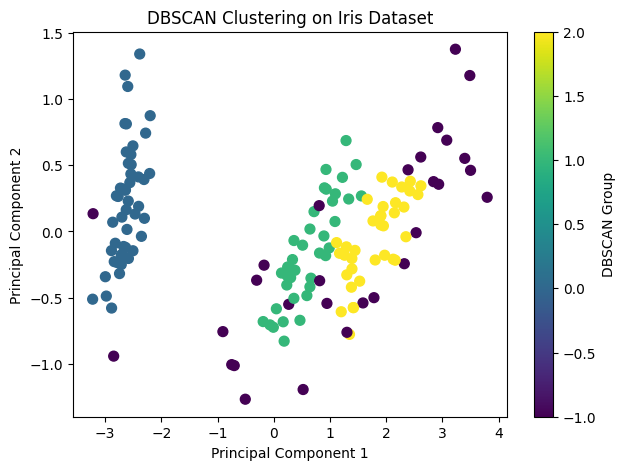

In [35]:
# plot dbscan groups

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=groups, cmap="viridis", s=50)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clustering on Iris Dataset")
plt.colorbar(label="DBSCAN Group")
plt.show()

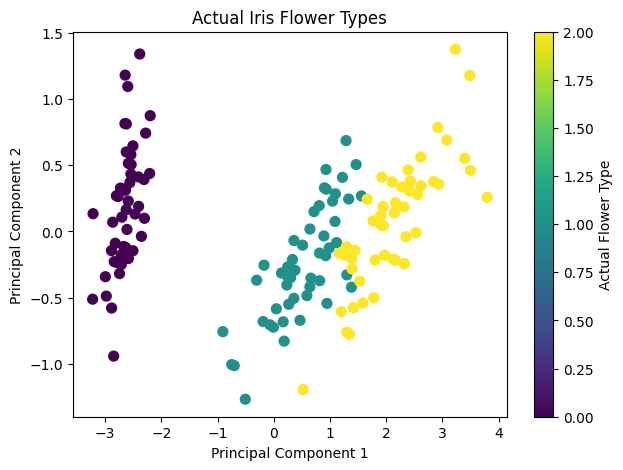

In [36]:
# plot flower labels

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis", s=50)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Actual Iris Flower Types")
plt.colorbar(label="Actual Flower Type")
plt.show()

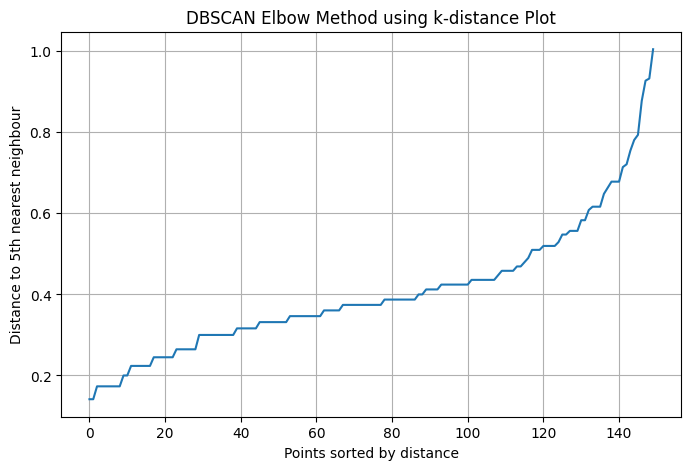

In [37]:
# elbow method

min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)

distances, indices = neighbors_fit.kneighbors(X)

k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbour")
plt.title("DBSCAN Elbow Method using k-distance Plot")
plt.grid(True)
plt.show()

In [38]:
# silhoutte coefficient

eps_values = np.arange(0.10, 1.51, 0.01)

silhouette_results = []

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(X)

    clusters = set(labels)
    clusters.discard(-1)

    n_clusters = len(clusters)
    n_noise = np.sum(labels == -1)

    if n_clusters >= 2:
        score = silhouette_score(X, labels)

        silhouette_results.append({
            "eps": round(eps, 2),
            "n_clusters": n_clusters,
            "noise_points": n_noise,
            "silhouette_score": score
        })

silhouette_df = pd.DataFrame(silhouette_results)

silhouette_df.head()

,eps,n_clusters,noise_points,silhouette_score
0,0.18,2,133,0.182564
1,0.19,2,133,0.182564
2,0.20,2,133,0.182564
3,0.21,2,133,0.182564
4,0.22,2,133,0.182564


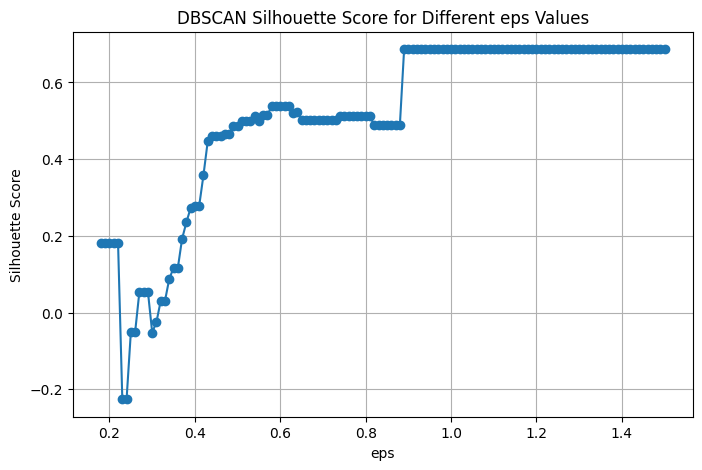

In [39]:
# plot silhoutte coefficient

plt.figure(figsize=(8, 5))
plt.plot(silhouette_df["eps"], silhouette_df["silhouette_score"], marker="o")
plt.xlabel("eps")
plt.ylabel("Silhouette Score")
plt.title("DBSCAN Silhouette Score for Different eps Values")
plt.grid(True)
plt.show()

In [40]:
# best silhoutte values

silhouette_df.sort_values(
    by="silhouette_score",
    ascending=False
).head(10)

,eps,n_clusters,noise_points,silhouette_score
128,1.46,2,0,0.686735
131,1.49,2,0,0.686735
132,1.50,2,0,0.686735
102,1.20,2,0,0.686735
101,1.19,2,0,0.686735
85,1.03,2,0,0.686735
86,1.04,2,0,0.686735
100,1.18,2,0,0.686735
99,1.17,2,0,0.686735
96,1.14,2,0,0.686735


In [43]:
# does scaling improve performance?

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

X_standard = standard_scaler.fit_transform(X)
X_minmax = minmax_scaler.fit_transform(X)

def evaluate_dbscan(X_data, y, dataset_name, target_clusters=3, min_samples=5):
    eps_search = find_eps_for_n_clusters(
        X_data,
        target_clusters=target_clusters,
        min_samples=min_samples
    )

    if eps_search.empty:
        return {
            "Dataset": dataset_name,
            "Best eps": None,
            "Clusters": None,
            "Noise points": None,
            "Accuracy excluding noise": None,
            "Overall accuracy": None,
            "Adjusted Rand Index": None,
            "Normalised Mutual Information": None,
            "Silhouette Score": None,
            "Note": "No eps found for exactly 3 clusters"
        }

    best_row = eps_search.sort_values(
        by="silhouette_score",
        ascending=False
    ).iloc[0]

    best_eps = best_row["eps"]

    model = DBSCAN(eps=best_eps, min_samples=min_samples)
    labels = model.fit_predict(X_data)

    clusters = set(labels)
    clusters.discard(-1)

    cluster_to_label = {}
    y_pred = np.full_like(y, fill_value=-1)

    for group in clusters:
        actual_labels_in_group = y[labels == group]
        most_common_label = np.bincount(actual_labels_in_group).argmax()

        cluster_to_label[group] = most_common_label
        y_pred[labels == group] = most_common_label

    assigned_mask = y_pred != -1

    if np.sum(assigned_mask) > 0:
        assigned_accuracy = accuracy_score(y[assigned_mask], y_pred[assigned_mask])
    else:
        assigned_accuracy = None

    overall_accuracy = np.mean(y_pred == y)

    if len(set(labels)) > 1:
        sil_score = silhouette_score(X_data, labels)
    else:
        sil_score = None

    return {
        "Dataset": dataset_name,
        "Best eps": best_eps,
        "Clusters": len(clusters),
        "Noise points": np.sum(labels == -1),
        "Accuracy excluding noise": assigned_accuracy,
        "Overall accuracy": overall_accuracy,
        "Adjusted Rand Index": adjusted_rand_score(y, labels),
        "Normalised Mutual Information": normalized_mutual_info_score(y, labels),
        "Silhouette Score": sil_score,
        "Note": "OK"
    }

comparison_results = []

comparison_results.append(evaluate_dbscan(X, y, "Unscaled"))
comparison_results.append(evaluate_dbscan(X_standard, y, "StandardScaler"))
comparison_results.append(evaluate_dbscan(X_minmax, y, "MinMaxScaler"))

comparison_df = pd.DataFrame(comparison_results)

comparison_df

,Dataset,Best eps,Clusters,Noise points,Accuracy excluding noise,Overall accuracy,Adjusted Rand Index,Normalised Mutual Information,Silhouette Score,Note
0,Unscaled,0.42,3,29,0.975207,0.786667,0.678917,0.698830,0.357892,OK
1,StandardScaler,0.47,3,44,0.933962,0.660000,0.533872,0.582445,0.235377,OK
2,MinMaxScaler,0.12,3,36,0.973684,0.740000,0.612048,0.640116,0.306404,OK


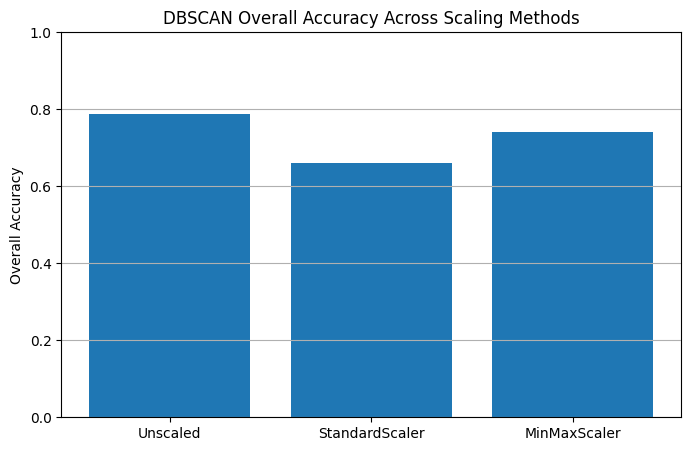

In [44]:
# plot scaling comparison

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Dataset"], comparison_df["Overall accuracy"])
plt.ylabel("Overall Accuracy")
plt.title("DBSCAN Overall Accuracy Across Scaling Methods")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

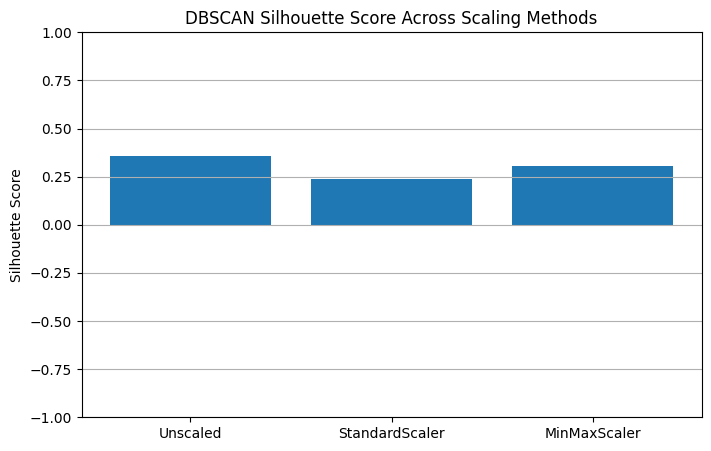

In [45]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Dataset"], comparison_df["Silhouette Score"])
plt.ylabel("Silhouette Score")
plt.title("DBSCAN Silhouette Score Across Scaling Methods")
plt.ylim(-1, 1)
plt.grid(axis="y")
plt.show()